In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

from sklearn.ensemble import VotingClassifier

In [3]:
df = pd.read_csv(r"C:\Users\Asus\Documents\GitHub\Telco-Customer-Churn\telco_churn_cleaned.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Target Variable Analysis (Churn)

In [4]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [5]:
print(df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean())
print(df.groupby('Churn')['gender'].value_counts())

          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     37.569965       61.265124   2549.911442
Yes    17.979133       74.441332   1531.796094
Churn  gender
No     Male      2625
       Female    2549
Yes    Female     939
       Male       930
Name: count, dtype: int64


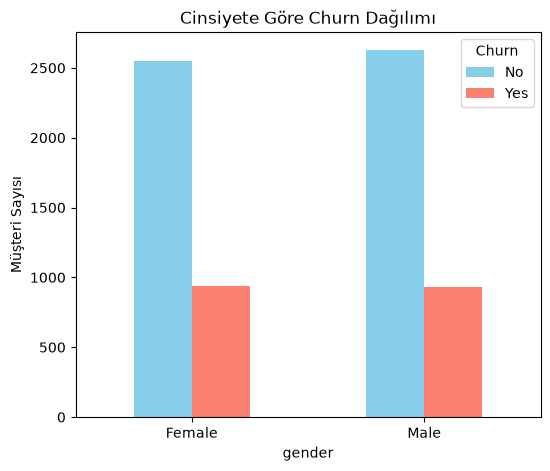

In [6]:
gender_churn = df.groupby('gender')['Churn'].value_counts().unstack()
gender_churn.plot(kind='bar', figsize=(6,5), color=['skyblue','salmon'])
plt.title('Cinsiyete Göre Churn Dağılımı')
plt.ylabel('Müşteri Sayısı')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


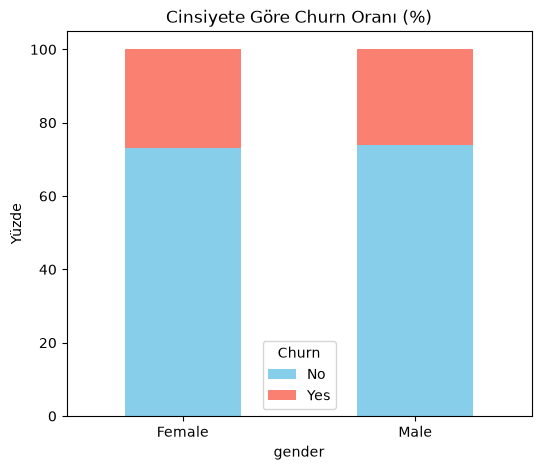

In [7]:
gender_churn_oran = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack() * 100
print(gender_churn_oran)

gender_churn_oran.plot(kind='bar', stacked=True, figsize=(6,5), color=['skyblue','salmon'])
plt.title('Cinsiyete Göre Churn Oranı (%)')
plt.ylabel('Yüzde')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

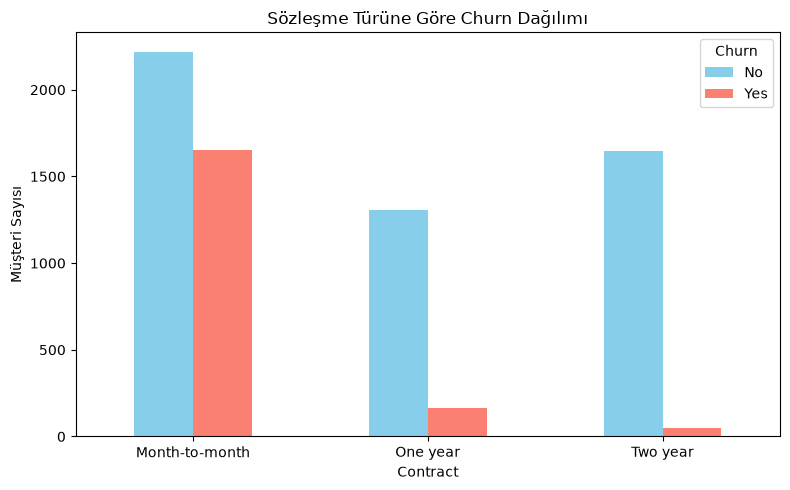

In [8]:
contract_churn = df.groupby('Contract')['Churn'].value_counts().unstack()
contract_churn.plot(kind='bar', figsize=(8,5), color=['skyblue','salmon'])
plt.title('Sözleşme Türüne Göre Churn Dağılımı')
plt.ylabel('Müşteri Sayısı')
plt.xlabel('Contract')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

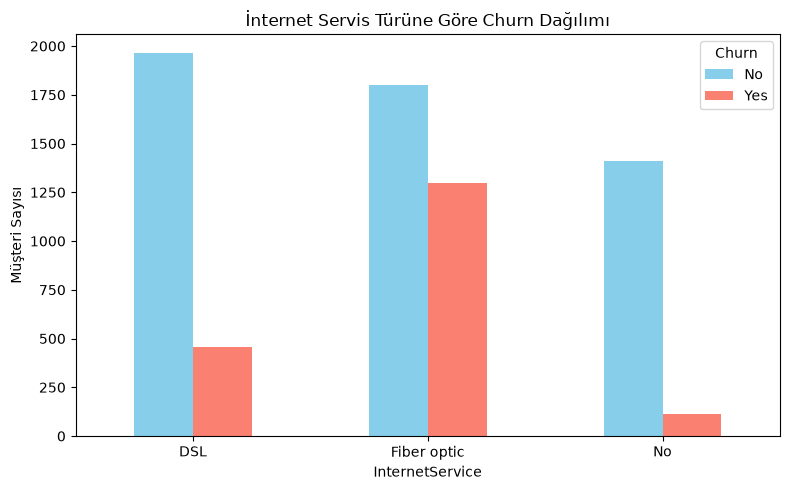

In [9]:
internet_churn = df.groupby('InternetService')['Churn'].value_counts().unstack()
internet_churn.plot(kind='bar', figsize=(8,5), color=['skyblue','salmon'])
plt.title('İnternet Servis Türüne Göre Churn Dağılımı')
plt.ylabel('Müşteri Sayısı')
plt.xlabel('InternetService')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

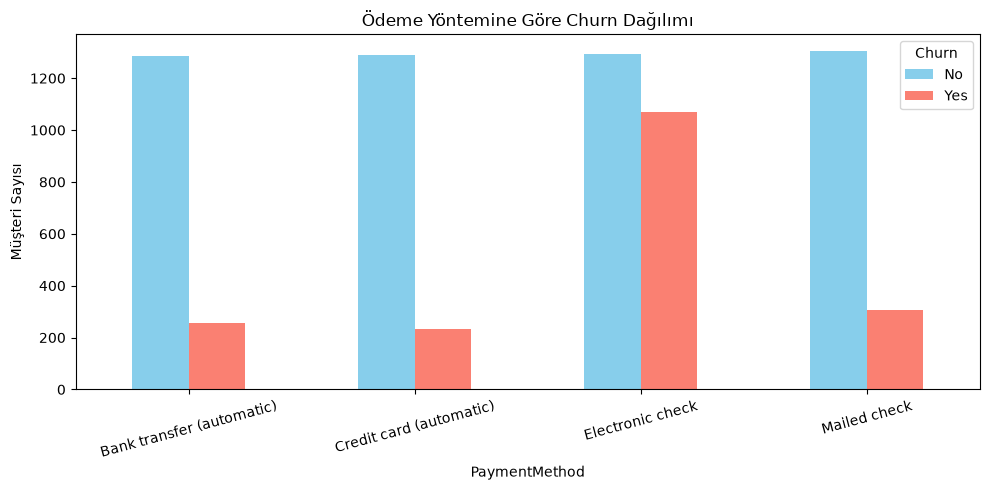

In [10]:
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts().unstack()
payment_churn.plot(kind='bar', figsize=(10,5), color=['skyblue','salmon'])
plt.title('Ödeme Yöntemine Göre Churn Dağılımı')
plt.ylabel('Müşteri Sayısı')
plt.xlabel('PaymentMethod')
plt.xticks(rotation=15)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


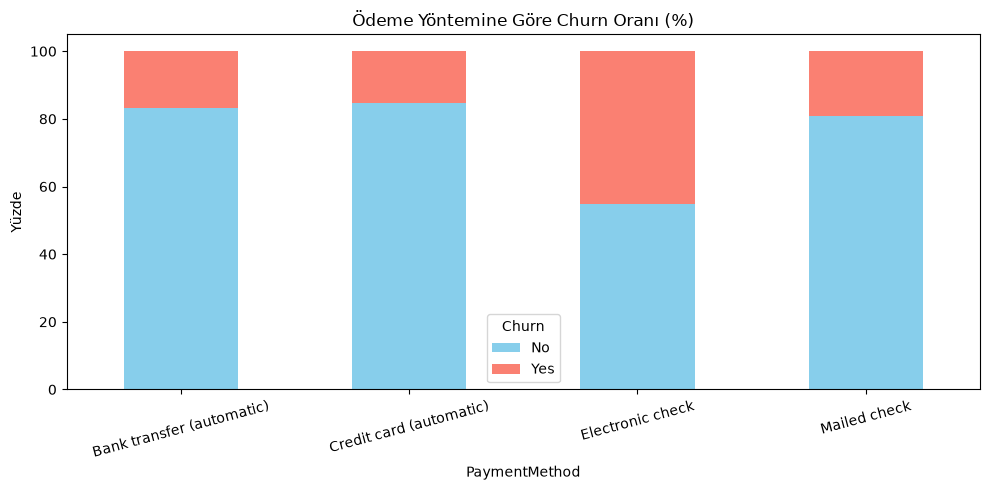

In [11]:
payment_churn_oran = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
print(payment_churn_oran)

payment_churn_oran.plot(kind='bar', stacked=True, figsize=(10,5), color=['skyblue','salmon'])
plt.title('Ödeme Yöntemine Göre Churn Oranı (%)')
plt.ylabel('Yüzde')
plt.xlabel('PaymentMethod')
plt.xticks(rotation=15)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


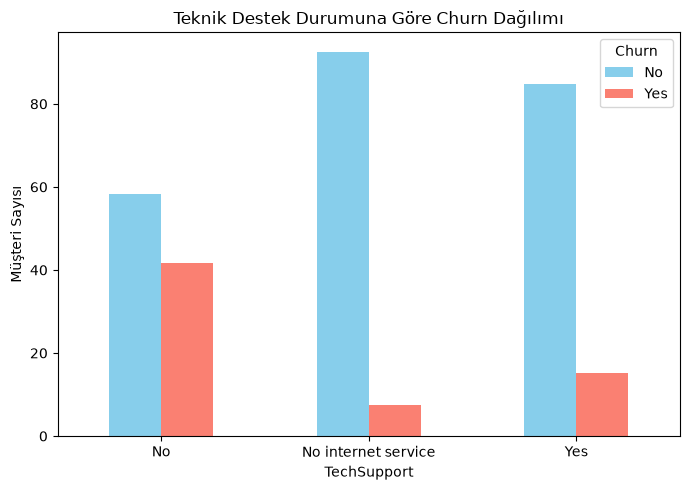

In [12]:
techsupport_churn = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100
print(techsupport_churn)

techsupport_churn.plot(kind='bar', figsize=(7,5), color=['skyblue','salmon'])
plt.title('Teknik Destek Durumuna Göre Churn Dağılımı')
plt.ylabel('Müşteri Sayısı')
plt.xlabel('TechSupport')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


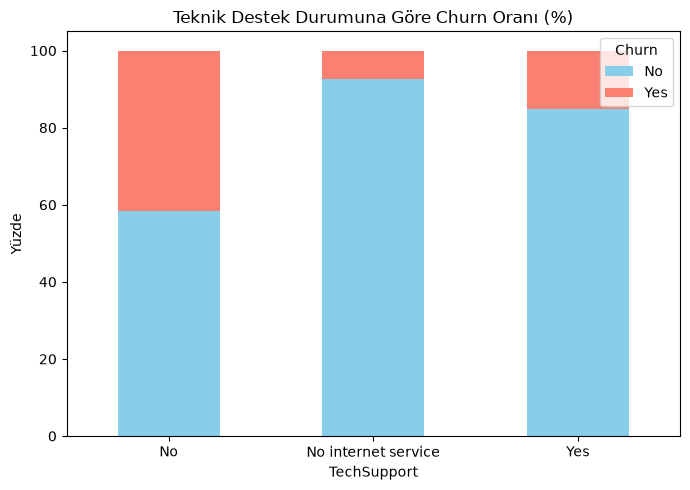

In [13]:
techsupport_churn_oran = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100
print(techsupport_churn_oran)

techsupport_churn_oran.plot(kind='bar', stacked=True, figsize=(7,5), color=['skyblue','salmon'])
plt.title('Teknik Destek Durumuna Göre Churn Oranı (%)')
plt.ylabel('Yüzde')
plt.xlabel('TechSupport')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

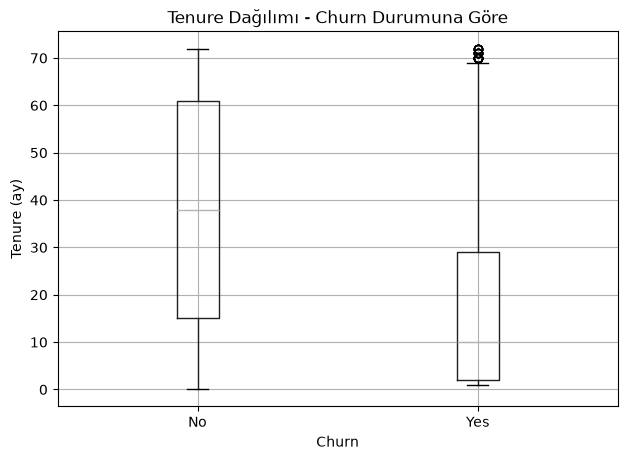

In [14]:
fig, ax = plt.subplots(figsize=(7,5))
df.boxplot(column='tenure', by='Churn', ax=ax)
plt.title('Tenure Dağılımı - Churn Durumuna Göre')
plt.suptitle('')  # otomatik üst başlığı kaldır
plt.xlabel('Churn')
plt.ylabel('Tenure (ay)')
plt.show()

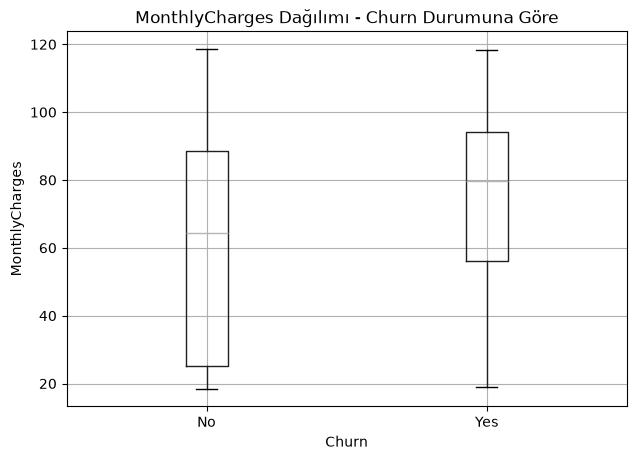

In [15]:
fig, ax = plt.subplots(figsize=(7,5))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax)
plt.title('MonthlyCharges Dağılımı - Churn Durumuna Göre')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('MonthlyCharges')
plt.show()

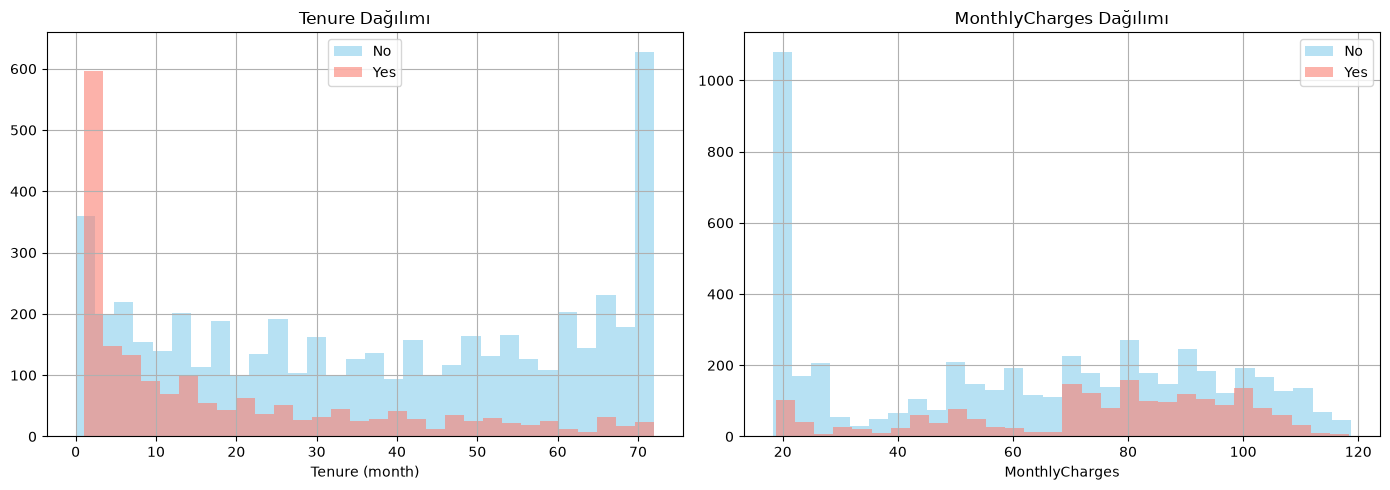

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df[df['Churn']=='No']['tenure'].hist(ax=axes[0], bins=30, alpha=0.6, label='No', color='skyblue')
df[df['Churn']=='Yes']['tenure'].hist(ax=axes[0], bins=30, alpha=0.6, label='Yes', color='salmon')
axes[0].set_title('Tenure Dağılımı')
axes[0].set_xlabel('Tenure (month)')
axes[0].legend()

df[df['Churn']=='No']['MonthlyCharges'].hist(ax=axes[1], bins=30, alpha=0.6, label='No', color='skyblue')
df[df['Churn']=='Yes']['MonthlyCharges'].hist(ax=axes[1], bins=30, alpha=0.6, label='Yes', color='salmon')
axes[1].set_title('MonthlyCharges Dağılımı')
axes[1].set_xlabel('MonthlyCharges')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
benzer_sutunlar = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'StreamingTV', 'StreamingMovies', 'MultipleLines']

for sutun in benzer_sutunlar:
    oran = df.groupby(sutun)['Churn'].value_counts(normalize=True).unstack() * 100
    print(f"\n{sutun}:")
    print(oran)


OnlineSecurity:
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

OnlineBackup:
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

DeviceProtection:
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064

StreamingTV:
Churn                       No        Yes
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188

StreamingMovies:
Churn                       No        Yes
StreamingMovies                    

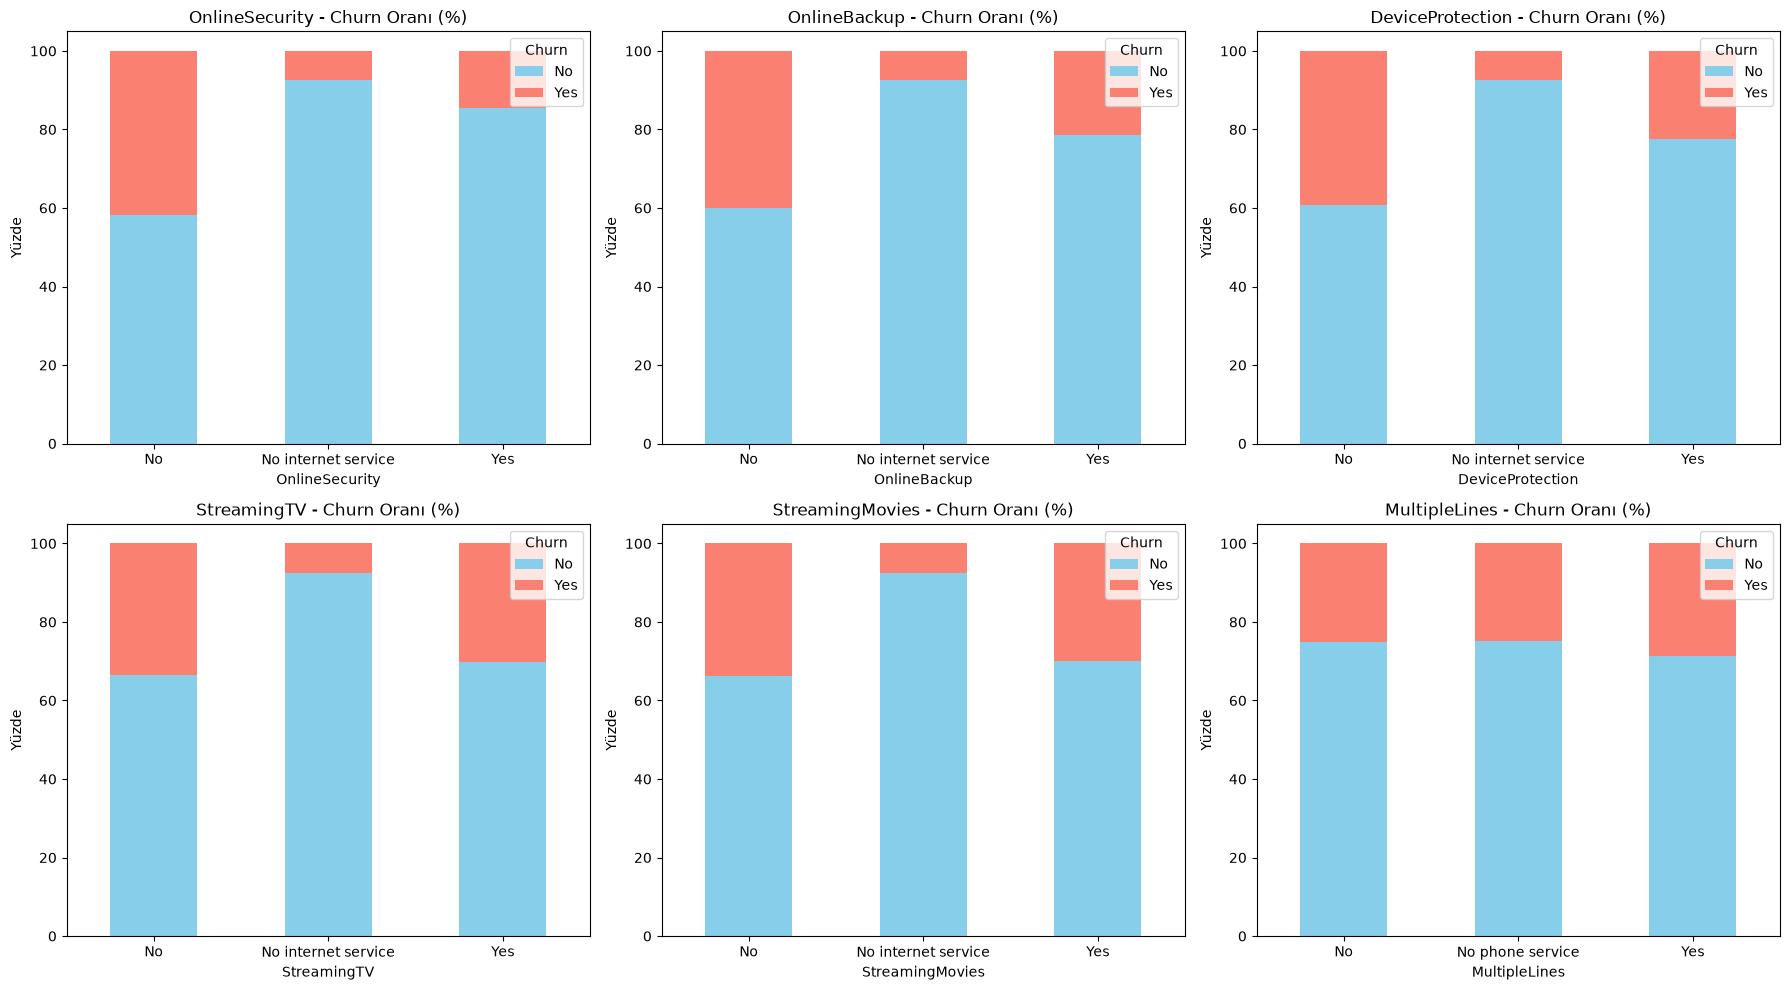

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sutun in enumerate(benzer_sutunlar):
    oran = df.groupby(sutun)['Churn'].value_counts(normalize=True).unstack() * 100
    oran.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue','salmon'])
    axes[i].set_title(f'{sutun} - Churn Oranı (%)')
    axes[i].set_ylabel('Yüzde')
    axes[i].set_xlabel(sutun)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Churn')

plt.tight_layout()
plt.show()

Bundling security and backup services into baseline internet packages can serve as an effective retention strategy to mitigate overall customer attrition
"If we want to reduce churn (customer churn), we should sell these additional services to customers through promotional campaigns."

# Cross-correlation analysis
  First, it will be necessary to apply an encoding to categorical variables, in addition to transforming variables with only two categories into dichotomous

In [19]:
vars_object = df.select_dtypes(include='object').columns
df_onehot = pd.get_dummies(df, columns=vars_object)

# İki kategorili (Yes/No, Male/Female) sütunlardan birini sil (gereksiz tekrar)
del df_onehot["gender_Male"]
del df_onehot["Partner_No"]
del df_onehot["Dependents_No"]
del df_onehot["PhoneService_No"]
del df_onehot["PaperlessBilling_No"]
del df_onehot["Churn_No"]

In [20]:
df_onehot = df_onehot.drop(columns=[col for col in df_onehot.columns if 'customerID' in col])

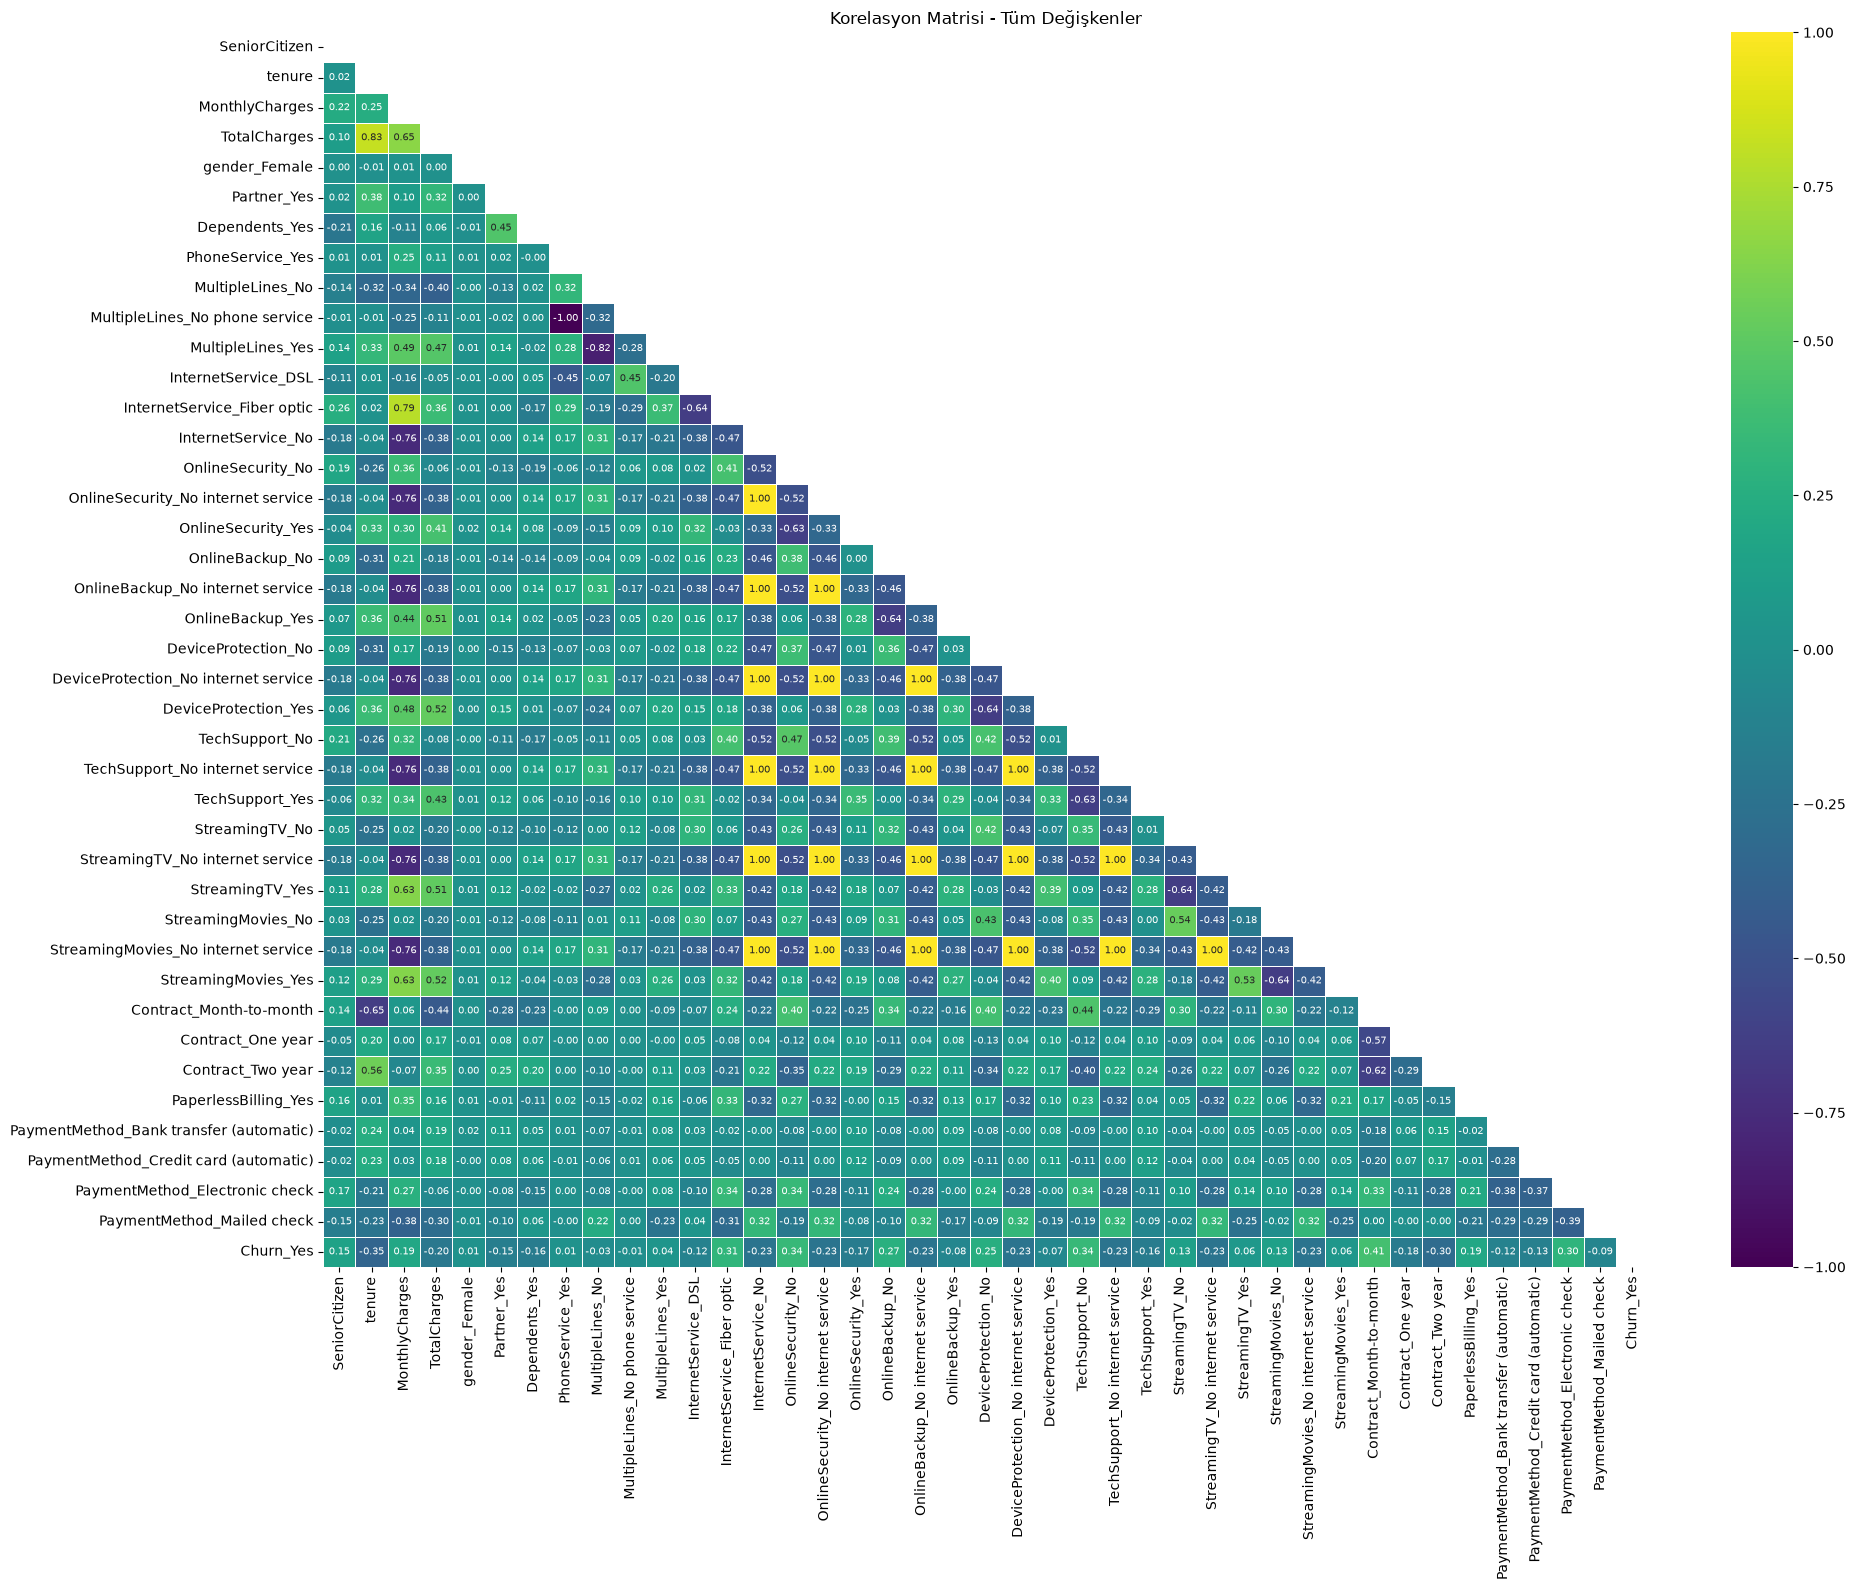

In [21]:
plt.figure(figsize=(20,16))
corrMatrix = df_onehot.corr()
mask = np.triu(np.ones_like(corrMatrix, dtype=bool))
sns.heatmap(corrMatrix, annot=True, cmap="viridis", linewidths=0.5, 
            linecolor='white', mask=mask, fmt='.2f', annot_kws={"size": 7})
plt.title('Korelasyon Matrisi - Tüm Değişkenler')
plt.tight_layout()
plt.show()

In [22]:
churn_corr = corrMatrix['Churn_Yes'].sort_values(ascending=False)
print(churn_corr)

Churn_Yes                                  1.000000
Contract_Month-to-month                    0.405103
OnlineSecurity_No                          0.342637
TechSupport_No                             0.337281
InternetService_Fiber optic                0.308020
PaymentMethod_Electronic check             0.301919
OnlineBackup_No                            0.268005
DeviceProtection_No                        0.252481
MonthlyCharges                             0.193356
PaperlessBilling_Yes                       0.191825
SeniorCitizen                              0.150889
StreamingMovies_No                         0.130845
StreamingTV_No                             0.128916
StreamingTV_Yes                            0.063228
StreamingMovies_Yes                        0.061382
MultipleLines_Yes                          0.040102
PhoneService_Yes                           0.011942
gender_Female                              0.008612
MultipleLines_No phone service            -0.011942
MultipleLine

In [23]:
# Bu sütunları sil - InternetService_No zaten aynı bilgiyi taşıyor
tekrar_eden_sutunlar = [
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service',
    'StreamingTV_No internet service',
    'StreamingMovies_No internet service',
    'MultipleLines_No phone service'
]

df_onehot = df_onehot.drop(columns=tekrar_eden_sutunlar)

In [24]:
no_sutunlar = ['MultipleLines_No', 'InternetService_No', 'OnlineSecurity_No', 
               'OnlineBackup_No', 'DeviceProtection_No', 'TechSupport_No', 
               'StreamingTV_No', 'StreamingMovies_No']

df_onehot = df_onehot.drop(columns=no_sutunlar)

In [25]:
no_sutunlar = [col for col in df_onehot.columns if col.endswith('_No')]
print(no_sutunlar)  # önce kontrol et, hangileri silinecek

[]


In [26]:
print(df_onehot.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Churn_Yes']


In [27]:
df_onehot = df_onehot.drop(columns=['Contract_Two year', 'PaymentMethod_Mailed check'])

User defined functions 

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def cf_plot(clf, X_train, X_test, y_train, y_test, method):
    acc_train = clf.score(X_train, y_train)
    acc_test = clf.score(X_test, y_test)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    
    cf_matrix_train = confusion_matrix(y_train, y_pred_train, normalize='true')
    cf_matrix_test = confusion_matrix(y_test, y_pred_test, normalize='true')
    
    disp_cf_matrix_train = ConfusionMatrixDisplay(cf_matrix_train, display_labels=['Not churn', 'Churn'])
    disp_cf_matrix_test = ConfusionMatrixDisplay(cf_matrix_test, display_labels=['Not churn', 'Churn'])
    
    f, axes = plt.subplots(1, 2, figsize=(12, 5), sharey='row')
    disp_cf_matrix_train.plot(ax=axes[0], cmap='Blues')
    disp_cf_matrix_train.ax_.set_xlabel('Predicted label\naccuracy={:0.4f}'.format(acc_train))
    disp_cf_matrix_test.plot(ax=axes[1], cmap='Blues')
    disp_cf_matrix_test.ax_.set_xlabel('Predicted label\naccuracy={:0.4f}'.format(acc_test))
    
    title_train = method + ' (Train)'
    title_test = method + ' (Test)'
    disp_cf_matrix_train.ax_.set_title(title_train)
    disp_cf_matrix_test.ax_.set_title(title_test)
    disp_cf_matrix_train.im_.colorbar.remove()
    disp_cf_matrix_test.im_.colorbar.remove()
    plt.tight_layout()
    plt.show()

TEST-TRAIN SPLIT 

In [37]:
from sklearn.model_selection import train_test_split

X = df_onehot.drop('Churn_Yes', axis=1)
y = df_onehot['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train boyutu: {X_train.shape}")
print(f"Test boyutu: {X_test.shape}")

Train boyutu: (5634, 23)
Test boyutu: (1409, 23)


In [38]:
print("Train Churn oranı:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest Churn oranı:")
print(y_test.value_counts(normalize=True) * 100)

Train Churn oranı:
Churn_Yes
False    73.464679
True     26.535321
Name: proportion, dtype: float64

Test Churn oranı:
Churn_Yes
False    73.456352
True     26.543648
Name: proportion, dtype: float64


Scenery 1.1 - Original dataset

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8005677785663591

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1035
        True       0.64      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



Scenery 1.2-Logistic Regression (class_weight='balanced') Attempted imbalance resolution

In [40]:
model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.7402413058907026

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.72      0.80      1035
        True       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



Scenery 1.3-RandomForestClassifier 

In [41]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7771469127040455

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.82      0.84      1035
        True       0.57      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



Scenery 1.4 Random Forest (GridSearch, tuned)

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                # 5-fold cross validation
    scoring='f1',        # f1-score'u optimize et (precision-recall dengesi için)
    n_jobs=-1,            # tüm işlemci çekirdeklerini kullan (hızlandırır)
    verbose=1             # ilerlemeyi göster
)

grid_search.fit(X_train, y_train)

print("En iyi parametreler:", grid_search.best_params_)
print("En iyi F1 skoru (CV):", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
En iyi parametreler: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
En iyi F1 skoru (CV): 0.6406084261266247


In [43]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Accuracy: 0.759403832505323

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.75      0.82      1035
        True       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [44]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# Her modelin olasılık tahminlerini al (1. sınıf = Churn Yes olasılığı)
y_prob_log = model.predict_proba(X_test)[:, 1]              # Logistic (normal)
y_prob_log_bal = model_balanced.predict_proba(X_test)[:, 1]  # Logistic (balanced)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]             # RF (varsayılan)
y_prob_rf_best = best_rf.predict_proba(X_test)[:, 1]         # RF (tuned)

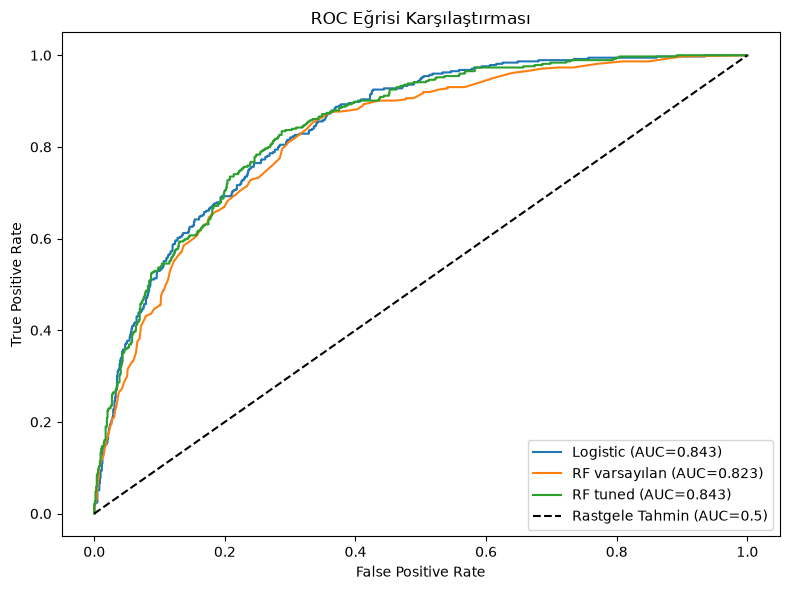

In [45]:
plt.figure(figsize=(8,6))

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_rf_best, tpr_rf_best, _ = roc_curve(y_test, y_prob_rf_best)

plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC={roc_auc_score(y_test, y_prob_log):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RF varsayılan (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot(fpr_rf_best, tpr_rf_best, label=f'RF tuned (AUC={roc_auc_score(y_test, y_prob_rf_best):.3f})')
plt.plot([0,1], [0,1], 'k--', label='Rastgele Tahmin (AUC=0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrisi Karşılaştırması')
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)
print(cm)

[[781 254]
 [ 85 289]]


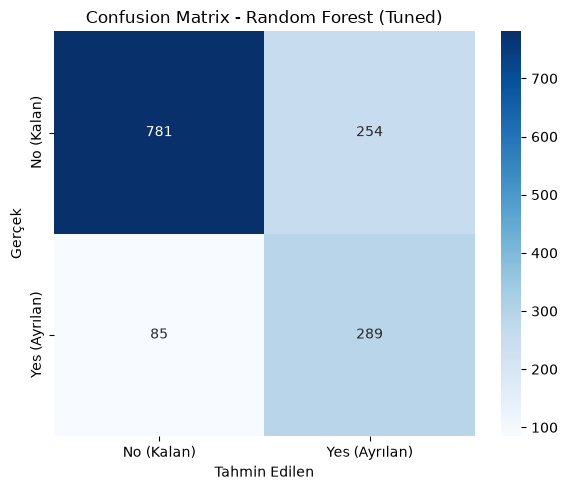

In [47]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No (Kalan)', 'Yes (Ayrılan)'],
            yticklabels=['No (Kalan)', 'Yes (Ayrılan)'])
plt.title('Confusion Matrix - Random Forest (Tuned)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

 Scenery 1.5 - SMOTE

In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE öncesi train boyutu:", X_train.shape)
print("SMOTE sonrası train boyutu:", X_train_smote.shape)
print("\nSMOTE öncesi churn dağılımı:")
print(y_train.value_counts())
print("\nSMOTE sonrası churn dağılımı:")
print(y_train_smote.value_counts())

SMOTE öncesi train boyutu: (5634, 23)
SMOTE sonrası train boyutu: (8278, 23)

SMOTE öncesi churn dağılımı:
Churn_Yes
False    4139
True     1495
Name: count, dtype: int64

SMOTE sonrası churn dağılımı:
Churn_Yes
False    4139
True     4139
Name: count, dtype: int64


In [49]:
model_rf_smote = RandomForestClassifier(n_estimators=200, max_depth=10, 
                                          min_samples_leaf=2, min_samples_split=10,
                                          random_state=42)
model_rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_rf_smote.predict(X_test)
y_prob_smote = model_rf_smote.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))
print("\nAUC:", roc_auc_score(y_test, y_prob_smote))

Accuracy: 0.7799858055358411

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.81      0.84      1035
        True       0.57      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409


AUC: 0.8407502131287299


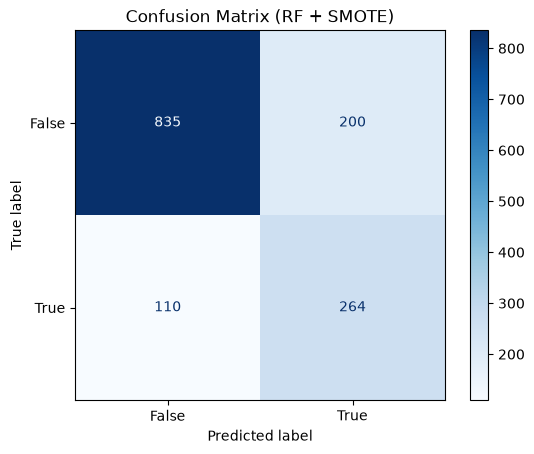

In [50]:
# 1. SMOTE'lu modeli tahmin ettirin
y_pred_smote = model_rf_smote.predict(X_test)

# 2. Confusion matrix'i yeni tahminlerle çizin
cm = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["False", "True"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (RF + SMOTE)")
plt.show()

Scenery 1.6 - XGBoost

In [55]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == False).sum() / (y_train == True).sum()

model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("\nAUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.7608232789212207

Classification Report:
              precision    recall  f1-score   support

       False       0.89      0.77      0.82      1035
        True       0.54      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


AUC: 0.8285928337079232


Scenery 1.7 - Dummy Classifier (a model that learns nothing)

In [36]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)

y_pred_dummy = dummy_clf.predict(X_test)
print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print(classification_report(y_test, y_pred_dummy))

Dummy Accuracy: 0.7345635202271115
              precision    recall  f1-score   support

       False       0.73      1.00      0.85      1035
        True       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



Scenery 1.8 - Tenure as categorical

In [31]:
def tenure_grup(ay):
    if ay <= 12:
        return 'tenure_group_1'   # 0-12 ay
    elif ay <= 24:
        return 'tenure_group_2'   # 13-24 ay
    elif ay <= 36:
        return 'tenure_group_3'   # 25-36 ay
    elif ay <= 48:
        return 'tenure_group_4'   # 37-48 ay
    else:
        return 'tenure_group_5+'  # 49+ ay

df['tenure_group'] = df['tenure'].apply(tenure_grup)
print(df['tenure_group'].value_counts())

tenure_group
tenure_group_5+    2239
tenure_group_1     2186
tenure_group_2     1024
tenure_group_3      832
tenure_group_4      762
Name: count, dtype: int64


In [32]:
# tenure_group'u dummy değişkenlere çevir
tenure_dummies = pd.get_dummies(df['tenure_group'], prefix='tenure_group')

# Orijinal df_onehot'tan tenure'ı çıkarıp, yerine tenure_group dummy'lerini ekleyelim
df_onehot_tenure = df_onehot.drop(columns=['tenure']).join(tenure_dummies)

print("Orijinal veri seti sütun sayısı:", df_onehot.shape[1])
print("Tenure-grup veri seti sütun sayısı:", df_onehot_tenure.shape[1])

Orijinal veri seti sütun sayısı: 24
Tenure-grup veri seti sütun sayısı: 28


In [33]:
X_tenure = df_onehot_tenure.drop('Churn_Yes', axis=1)
y_tenure = df_onehot_tenure['Churn_Yes']

X_train_tenure, X_test_tenure, y_train_tenure, y_test_tenure = train_test_split(
    X_tenure, y_tenure, test_size=0.2, random_state=42, stratify=y_tenure
)

print("X_train_tenure boyutu:", X_train_tenure.shape)

X_train_tenure boyutu: (5634, 27)


In [35]:

from sklearn.metrics import roc_auc_score

print("\nAUC:", roc_auc_score(y_test_tenure, y_prob_tenure))
model_rf_tenure = RandomForestClassifier(n_estimators=200, max_depth=10,
                                           min_samples_leaf=2, min_samples_split=10,
                                           random_state=42, class_weight='balanced')
model_rf_tenure.fit(X_train_tenure, y_train_tenure)

y_pred_tenure = model_rf_tenure.predict(X_test_tenure)
y_prob_tenure = model_rf_tenure.predict_proba(X_test_tenure)[:, 1]

print("Accuracy:", accuracy_score(y_test_tenure, y_pred_tenure))
print("\nClassification Report:")
print(classification_report(y_test_tenure, y_pred_tenure))
print("\nAUC:", roc_auc_score(y_test_tenure, y_prob_tenure))


AUC: 0.8407786302926968
Accuracy: 0.7572746628814763

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.75      0.82      1035
        True       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


AUC: 0.8407786302926968


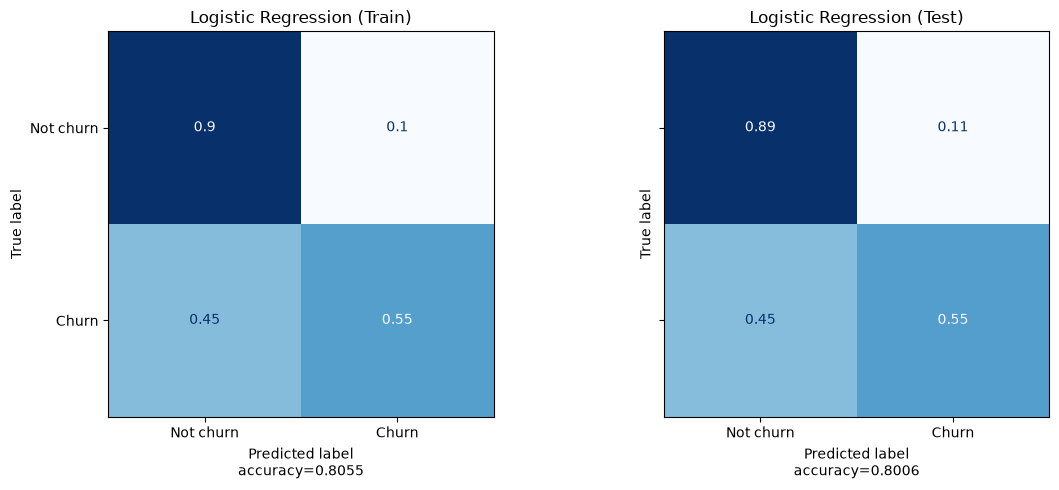

In [51]:
cf_plot(model, X_train, X_test, y_train, y_test, "Logistic Regression")

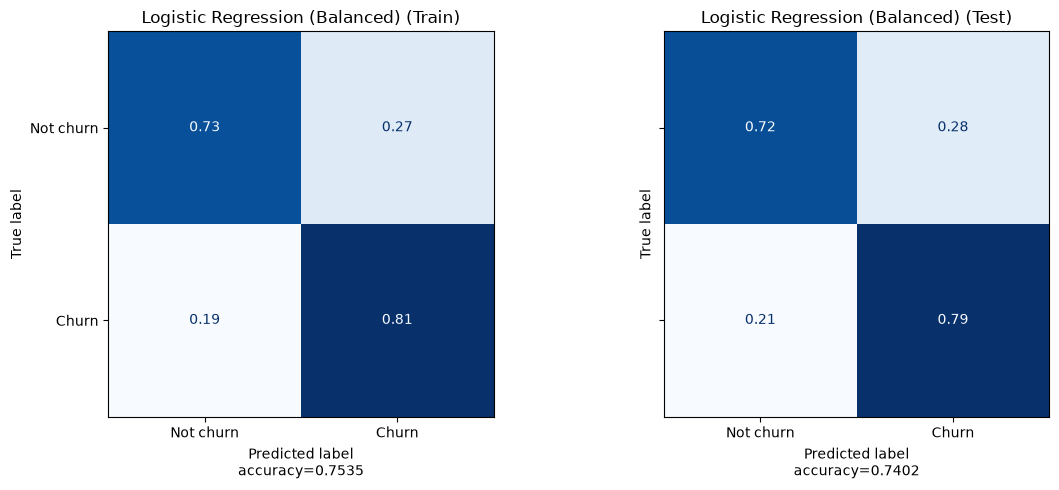

In [52]:
cf_plot(model_balanced, X_train, X_test, y_train, y_test, "Logistic Regression (Balanced)")

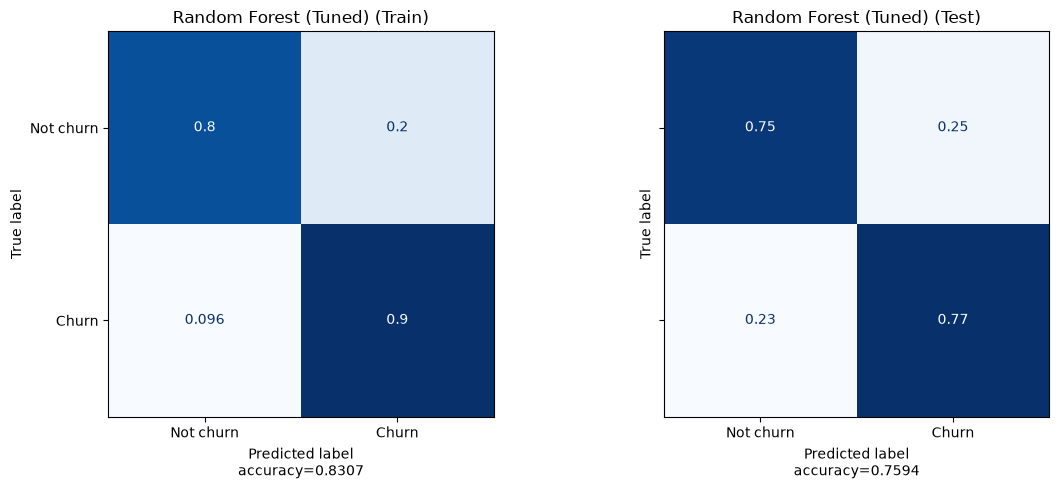

In [53]:
cf_plot(best_rf, X_train, X_test, y_train, y_test, "Random Forest (Tuned)")

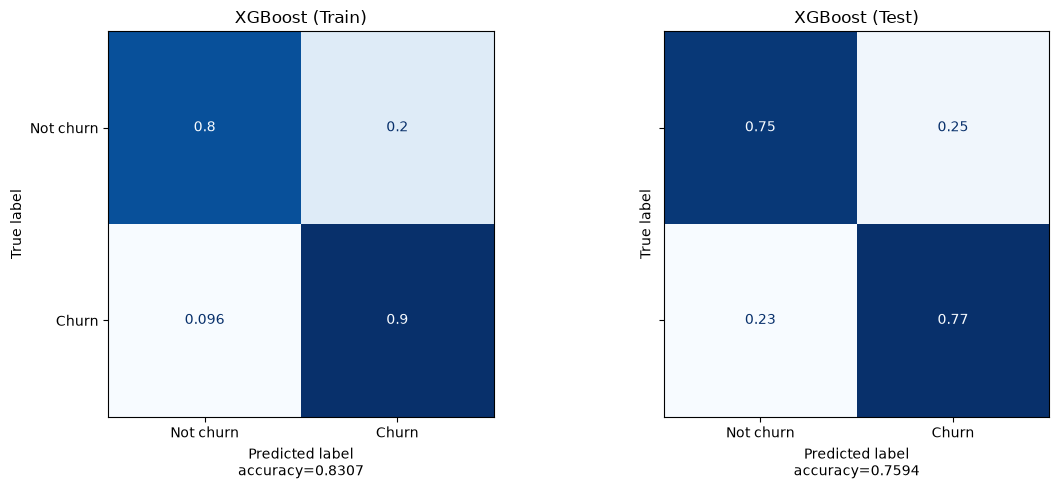

In [56]:
cf_plot(best_rf, X_train, X_test, y_train, y_test, "XGBoost")

In [57]:
df_pred = pd.DataFrame()
df_pred['churn_propensity'] = best_rf.predict_proba(X_test)[:, 1]  # ayrılma olasılığı
df_pred['churn_pred'] = best_rf.predict(X_test)                     # model tahmini (0/1)  
df_pred['churn_true'] = y_test.values                                # gerçek değer

df_pred.head()

,churn_propensity,churn_pred,churn_true
0,0.034545,False,False
1,0.877033,True,False
2,0.128406,False,False
3,0.602857,True,False
4,0.036699,False,False


Most important features

In [65]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Değişken': X_train.columns,
    'Önem': best_rf.feature_importances_
}).sort_values('Önem', ascending=False)

print(feature_importance)

                                   Değişken      Önem
1                                    tenure  0.164393
17                  Contract_Month-to-month  0.163963
3                              TotalCharges  0.132589
2                            MonthlyCharges  0.125659
10              InternetService_Fiber optic  0.100778
22           PaymentMethod_Electronic check  0.054922
19                     PaperlessBilling_Yes  0.027645
9                       InternetService_DSL  0.023234
11                       OnlineSecurity_Yes  0.023192
18                        Contract_One year  0.021855
14                          TechSupport_Yes  0.021257
6                            Dependents_Yes  0.014815
16                      StreamingMovies_Yes  0.014479
12                         OnlineBackup_Yes  0.014178
15                          StreamingTV_Yes  0.013554
5                               Partner_Yes  0.012542
4                             gender_Female  0.011724
0                           

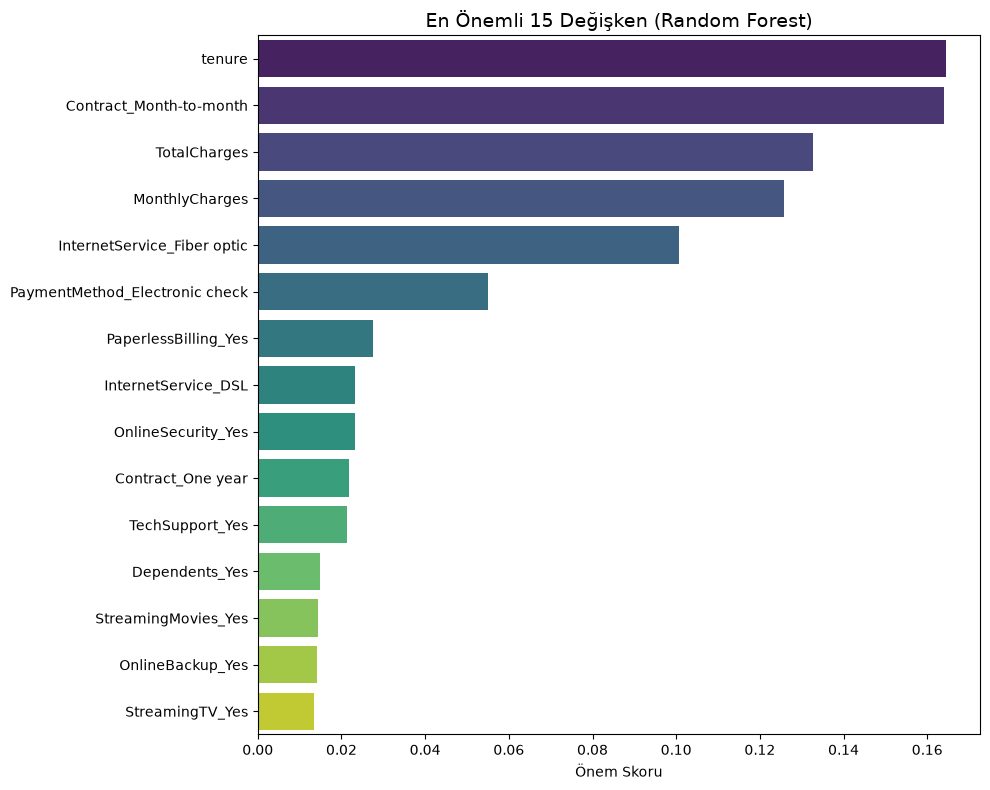

In [66]:
plt.figure(figsize=(10,8))
sns.barplot(
    data=feature_importance.head(15),
    x='Önem',
    y='Değişken',
    hue='Değişken',
    palette='viridis',
    legend=False
)
plt.title('En Önemli 15 Değişken (Random Forest)', fontsize=14)
plt.xlabel('Önem Skoru')
plt.ylabel('')
plt.tight_layout()
plt.show()

"Decile analysis provides a tabular breakdown of model performance and serves as an effective segmentation tool.

Based on this analysis, we can pinpoint the churn propensity tiers that deliver the highest expected financial return, enabling targeted retention and marketing campaigns toward high-risk, high-value customers."

In [58]:
df_pred['decile'] = pd.qcut(df_pred['churn_propensity'], 10, duplicates='drop')

decile_table = df_pred.groupby('decile').agg(
    musteri_sayisi=('churn_true', 'count'),
    gercek_churn=('churn_true', 'sum'),
    tahmin_churn=('churn_pred', 'sum')
).sort_index(ascending=False)  # en yüksek riskli dilim en üstte

decile_table['churn_orani'] = (decile_table['gercek_churn'] / decile_table['musteri_sayisi'] * 100).round(1)
print(decile_table)

                   musteri_sayisi  gercek_churn  tahmin_churn  churn_orani
decile                                                                    
(0.813, 0.959]                141           104           141         73.8
(0.716, 0.813]                141            88           141         62.4
(0.608, 0.716]                141            48           141         34.0
(0.477, 0.608]                141            56           120         39.7
(0.352, 0.477]                140            32             0         22.9
(0.255, 0.352]                141            22             0         15.6
(0.155, 0.255]                141            14             0          9.9
(0.0853, 0.155]               141             6             0          4.3
(0.0345, 0.0853]              141             3             0          2.1
(0.00212, 0.0345]             141             1             0          0.7


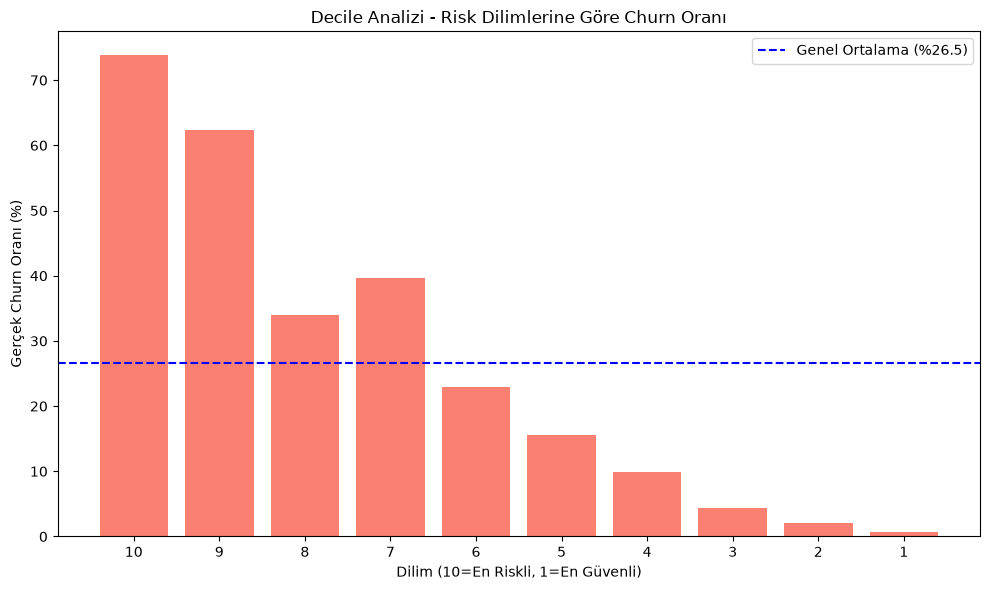

In [59]:
plt.figure(figsize=(10,6))
plt.bar(range(len(decile_table)), decile_table['churn_orani'], color='salmon')
plt.axhline(y=df_pred['churn_true'].mean()*100, color='blue', linestyle='--', 
            label=f'Genel Ortalama (%{df_pred["churn_true"].mean()*100:.1f})')
plt.xlabel('Dilim (10=En Riskli, 1=En Güvenli)')
plt.ylabel('Gerçek Churn Oranı (%)')
plt.title('Decile Analizi - Risk Dilimlerine Göre Churn Oranı')
plt.xticks(range(len(decile_table)), range(10,0,-1))
plt.legend()
plt.tight_layout()
plt.show()

By focusing on just the top 564 highest-risk customers (the top 4 deciles) instead of all 1,409 customers, the company can identify 79% of customers who will actually churn (296 out of 374). This means that by targeting only 40% of the customer base with retention campaigns, the company can potentially prevent up to 79% of expected customer losses — a highly efficient targeting strategy that significantly improves marketing ROI compared to a blanket, untargeted approach.

In [60]:
# Decile tablosunu yeniden oluşturalım (1=en riskli olacak şekilde)
df_pred['decile'] = pd.qcut(df_pred['churn_propensity'], 10, labels=False, duplicates='drop')
df_pred['decile'] = 10 - df_pred['decile']  # 0=en düşük olasılık -> 10, ters çevirelim (1=en riskli)

decile_table = df_pred.groupby('decile').agg(
    musteri_sayisi=('churn_true', 'count'),
    gercek_churn=('churn_true', 'sum'),
).sort_index()  # 1'den 10'a sıralı (1=en riskli)

decile_table['kalan'] = decile_table['musteri_sayisi'] - decile_table['gercek_churn']
decile_table['churn_orani'] = (decile_table['gercek_churn'] / decile_table['musteri_sayisi'] * 100).round(2)

# Kümülatif yüzdeler
decile_table['churn_cum_pct'] = (decile_table['gercek_churn'].cumsum() / decile_table['gercek_churn'].sum() * 100).round(2)
decile_table['not_churn_cum_pct'] = (decile_table['kalan'].cumsum() / decile_table['kalan'].sum() * 100).round(2)

print(decile_table)

        musteri_sayisi  gercek_churn  kalan  churn_orani  churn_cum_pct  \
decile                                                                    
1                  141           104     37        73.76          27.81   
2                  141            88     53        62.41          51.34   
3                  141            48     93        34.04          64.17   
4                  141            56     85        39.72          79.14   
5                  140            32    108        22.86          87.70   
6                  141            22    119        15.60          93.58   
7                  141            14    127         9.93          97.33   
8                  141             6    135         4.26          98.93   
9                  141             3    138         2.13          99.73   
10                 141             1    140         0.71         100.00   

        not_churn_cum_pct  
decile                     
1                    3.57  
2              

In [61]:
genel_churn_orani = df_pred['churn_true'].mean() * 100

decile_table['lift'] = (decile_table['churn_orani'] / genel_churn_orani).round(2)
decile_table['KS'] = (abs(decile_table['churn_cum_pct'] - decile_table['not_churn_cum_pct']) / 100).round(2)

print(decile_table)

        musteri_sayisi  gercek_churn  kalan  churn_orani  churn_cum_pct  \
decile                                                                    
1                  141           104     37        73.76          27.81   
2                  141            88     53        62.41          51.34   
3                  141            48     93        34.04          64.17   
4                  141            56     85        39.72          79.14   
5                  140            32    108        22.86          87.70   
6                  141            22    119        15.60          93.58   
7                  141            14    127         9.93          97.33   
8                  141             6    135         4.26          98.93   
9                  141             3    138         2.13          99.73   
10                 141             1    140         0.71         100.00   

        not_churn_cum_pct  lift    KS  
decile                                 
1                  

In [62]:
def propensity_label(lift):
    if lift >= 2.0:
        return 'High propensity'
    elif lift >= 1.2:
        return 'Medium propensity'
    elif lift >= 0.6:
        return 'Low propensity'
    else:
        return 'Not propensity'

decile_table['propensity'] = decile_table['lift'].apply(propensity_label)
print(decile_table)

        musteri_sayisi  gercek_churn  kalan  churn_orani  churn_cum_pct  \
decile                                                                    
1                  141           104     37        73.76          27.81   
2                  141            88     53        62.41          51.34   
3                  141            48     93        34.04          64.17   
4                  141            56     85        39.72          79.14   
5                  140            32    108        22.86          87.70   
6                  141            22    119        15.60          93.58   
7                  141            14    127         9.93          97.33   
8                  141             6    135         4.26          98.93   
9                  141             3    138         2.13          99.73   
10                 141             1    140         0.71         100.00   

        not_churn_cum_pct  lift    KS         propensity  
decile                                  

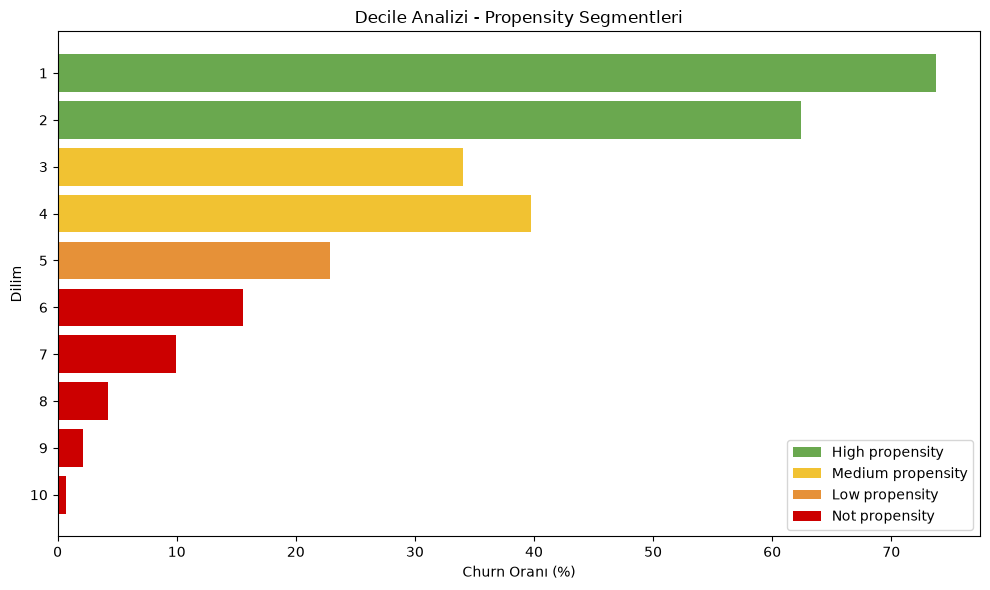

In [63]:
import matplotlib.colors as mcolors

renk_map = {
    'High propensity': '#6aa84f',
    'Medium propensity': '#f1c232',
    'Low propensity': '#e69138',
    'Not propensity': '#cc0000'
}

renkler = decile_table['propensity'].map(renk_map)

plt.figure(figsize=(10,6))
plt.barh(decile_table.index.astype(str), decile_table['churn_orani'], color=renkler)
plt.gca().invert_yaxis()  # dilim 1 en üstte
plt.xlabel('Churn Oranı (%)')
plt.ylabel('Dilim')
plt.title('Decile Analizi - Propensity Segmentleri')

# Lejant ekle
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=renk, label=etiket) for etiket, renk in renk_map.items()]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [64]:
en_iyi_ks_dilim = decile_table['KS'].idxmax()
print(f"En yüksek ayırt edicilik (KS={decile_table['KS'].max()}), Dilim {en_iyi_ks_dilim}'de")

En yüksek ayırt edicilik (KS=0.53), Dilim 4'de
